# Data Preparation — Churn Prediction
## HPB Fintech Hackathon 2026

**Input:** Raw features from EDA (`churn_features_raw.csv`) — single period, 10 features
**Output:** Clean, training-ready dataset (`churn_features_clean.csv`)

### Steps
1. Load and inspect raw features
2. Handle missing values
3. Analyze feature distributions
4. Verify low mutual correlation
5. Export clean dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

from pathlib import Path
PROCESSED = Path('../data/processed')

df = pd.read_csv(PROCESSED / 'churn_features_raw.csv')
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Churn rate: {df["churned"].mean():.1%}')
print()
df.info()

Dataset: 7,805 rows x 12 columns
Churn rate: 1.7%

<class 'pandas.DataFrame'>
RangeIndex: 7805 entries, 0 to 7804
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   client_id          7805 non-null   str    
 1   tenure_years       7805 non-null   float64
 2   n_products         7805 non-null   int64  
 3   has_loan           7805 non-null   int64  
 4   receives_salary    7805 non-null   int64  
 5   avg_txn_per_month  5247 non-null   float64
 6   avg_txn_amount     5247 non-null   float64
 7   txn_trend          5247 non-null   float64
 8   avg_balance        3767 non-null   float64
 9   balance_trend      3767 non-null   float64
 10  n_contacts         887 non-null    float64
 11  churned            7805 non-null   int64  
dtypes: float64(7), int64(4), str(1)
memory usage: 731.8 KB


## 1. Missing Value Analysis

In [4]:
FEATURES = ['tenure_years', 'n_products', 'has_loan', 'receives_salary',
            'avg_txn_per_month', 'avg_txn_amount', 'txn_trend',
            'avg_balance', 'balance_trend', 'n_contacts']

missing = df[FEATURES].isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
miss_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct}).query('Missing > 0')
print('Missing values:')
if len(miss_df) > 0:
    print(miss_df.to_string())
else:
    print('  None')

# Imputation strategy:
# - Behavioral features (txn, balance, contact): NaN = no activity → fill with 0
# - Demographic features (tenure): fill with median
behavioral = ['avg_txn_per_month', 'avg_txn_amount', 'txn_trend',
              'avg_balance', 'balance_trend', 'n_contacts']
demographic = ['tenure_years']

for col in behavioral:
    n_filled = df[col].isnull().sum()
    df[col] = df[col].fillna(0)
    if n_filled > 0:
        print(f'  {col}: filled {n_filled:,} NaN with 0')

for col in demographic:
    n_filled = df[col].isnull().sum()
    if n_filled > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'  {col}: filled {n_filled:,} NaN with median ({median_val:.1f})')

print(f'\nRemaining NaN: {df[FEATURES].isnull().sum().sum()}')

Missing values:
                   Missing   Pct
avg_txn_per_month     2558  32.8
avg_txn_amount        2558  32.8
txn_trend             2558  32.8
avg_balance           4038  51.7
balance_trend         4038  51.7
n_contacts            6918  88.6
  avg_txn_per_month: filled 2,558 NaN with 0
  avg_txn_amount: filled 2,558 NaN with 0
  txn_trend: filled 2,558 NaN with 0
  avg_balance: filled 4,038 NaN with 0
  balance_trend: filled 4,038 NaN with 0
  n_contacts: filled 6,918 NaN with 0

Remaining NaN: 0


## 2. Feature Distributions

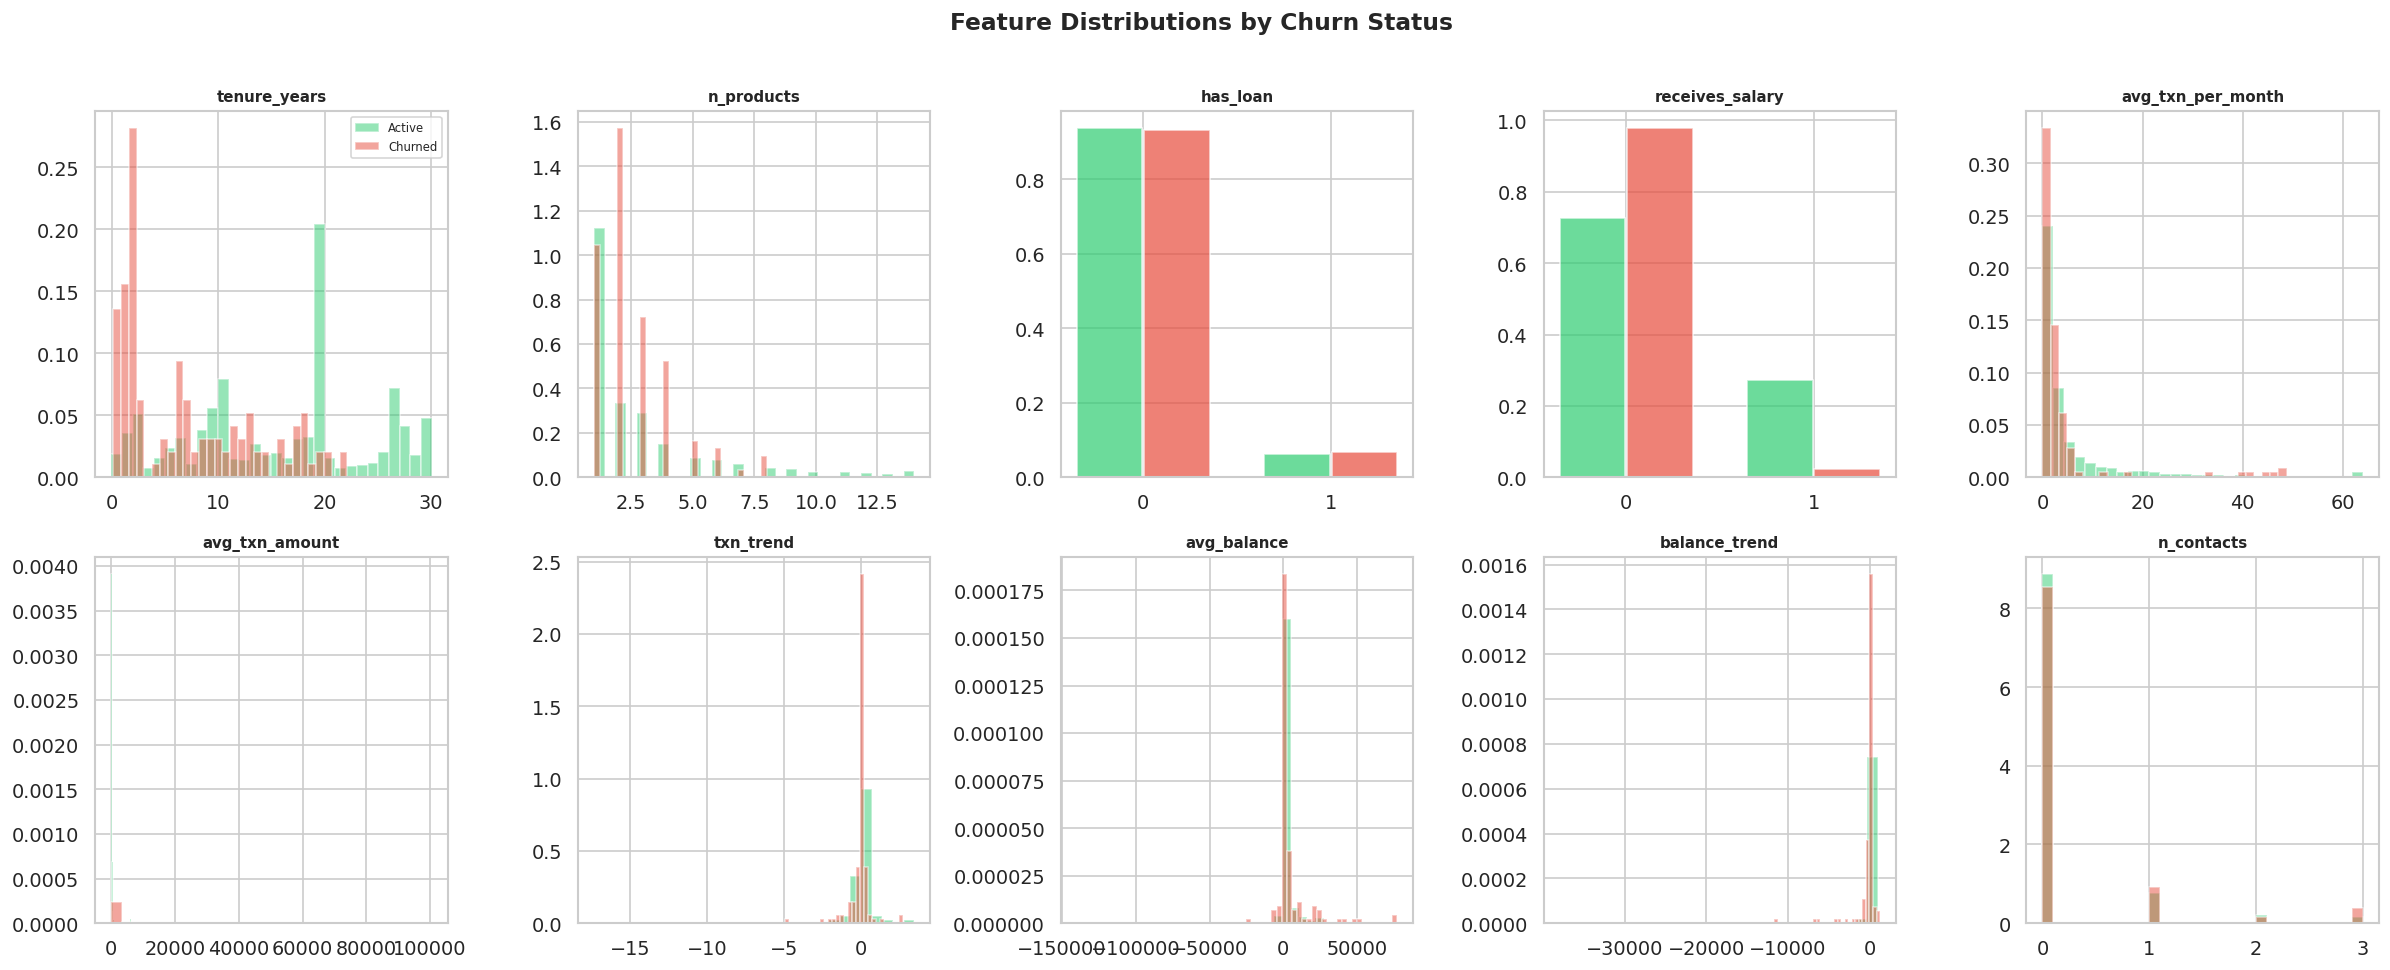

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

binary_features = {'has_loan', 'receives_salary'}

for i, col in enumerate(FEATURES):
    ax = axes[i]
    for val, label, color in [(0, 'Active', '#2ecc71'), (1, 'Churned', '#e74c3c')]:
        subset = df.loc[df['churned'] == val, col].dropna()
        if col in binary_features:
            vals = [0, 1]
            counts = subset.value_counts(normalize=True).reindex(vals, fill_value=0)
            offset = -0.18 if val == 0 else 0.18
            ax.bar([v + offset for v in vals], counts.values,
                   alpha=0.7, color=color, width=0.35, label=label)
            ax.set_xticks([0, 1])
        else:
            clipped = subset.clip(upper=subset.quantile(0.99))
            ax.hist(clipped, bins=30, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(col, fontweight='bold', fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle('Feature Distributions by Churn Status', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Correlation Check & Export

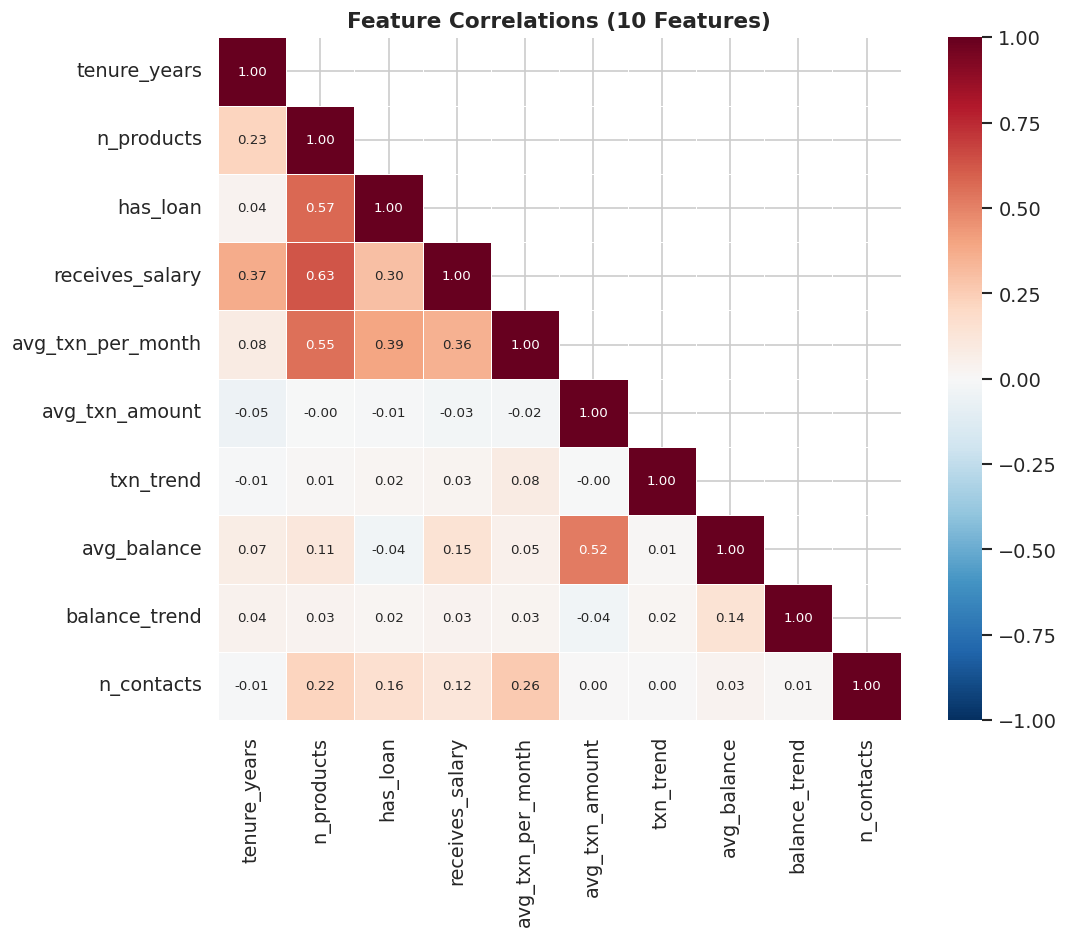

No feature pairs with |r| > 0.8 — all 10 features retained.

Correlation with churn target:
tenure_years         0.1320
avg_txn_amount       0.1243
receives_salary      0.0723
avg_balance          0.0584
avg_txn_per_month    0.0208
balance_trend        0.0199
n_products           0.0117
n_contacts           0.0061
txn_trend            0.0053
has_loan             0.0028


In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-1, vmax=1, square=True, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Feature Correlations (10 Features)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Check for highly correlated pairs (|r| > 0.8)
high_corr = []
for i in range(len(FEATURES)):
    for j in range(i+1, len(FEATURES)):
        r = abs(corr.iloc[i, j])
        if r > 0.8:
            high_corr.append((FEATURES[i], FEATURES[j], r))

if high_corr:
    print('Highly correlated pairs (|r| > 0.8):')
    for f1, f2, r in sorted(high_corr, key=lambda x: -x[2]):
        print(f'  {f1} <-> {f2}: {r:.3f}')
else:
    print('No feature pairs with |r| > 0.8 — all 10 features retained.')

# Point-biserial correlation with target
target_corr = df[FEATURES].corrwith(df['churned']).abs().sort_values(ascending=False)
print(f'\nCorrelation with churn target:')
print(target_corr.round(4).to_string())

In [7]:
# ── Export Clean Dataset ──
print(f'Final feature set ({len(FEATURES)} features):')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')

out = df[['client_id'] + FEATURES + ['churned']].copy()
out_path = PROCESSED / 'churn_features_clean.csv'
out.to_csv(out_path, index=False)
print(f'\nExported: {out_path}')
print(f'  Shape: {out.shape}')
print(f'  Churn rate: {out["churned"].mean():.1%}')

Final feature set (10 features):
   1. tenure_years
   2. n_products
   3. has_loan
   4. receives_salary
   5. avg_txn_per_month
   6. avg_txn_amount
   7. txn_trend
   8. avg_balance
   9. balance_trend
  10. n_contacts

Exported: ../data/processed/churn_features_clean.csv
  Shape: (7805, 12)
  Churn rate: 1.7%
